Project Overview
This project uses machine learning to predict whether a wine is high quality based on its chemical profile. It automates a process that typically requires expensive, expert human tasting.

Load Libraries and Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load the dataset
df = pd.read_csv('/content/WineQT.csv')

# Drop 'Id' column if it exists, as it isn't a chemical feature
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Display the first few rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Exploratory Data Analysis (EDA)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


/tmp/ipykernel_946/1768900972.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='muted')


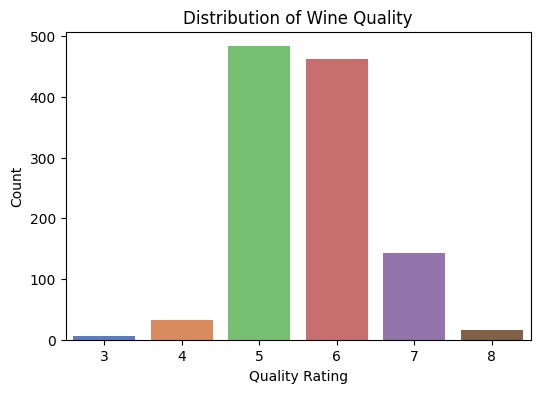

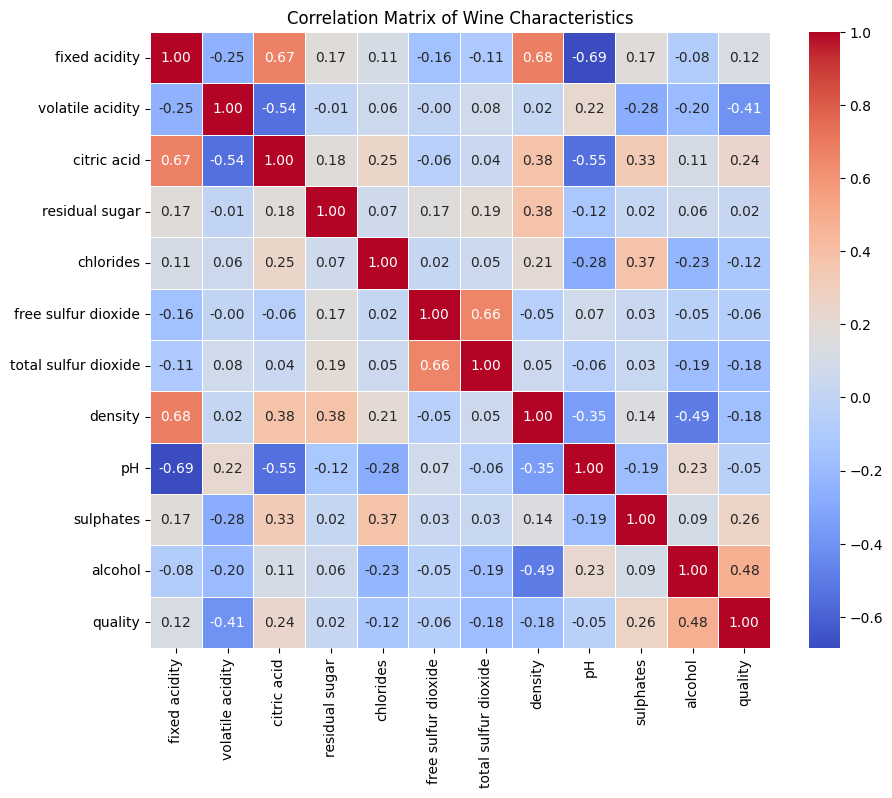

In [4]:
# Check basic dataset information and missing values
print("--- Dataset Info ---")
df.info()

# Visualizing the distribution of wine quality
plt.figure(figsize=(6, 4))
sns.countplot(x='quality', data=df, palette='muted')
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.show()

# Visualizing correlations using a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Wine Characteristics')
plt.show()

Data Preprocessing

In [5]:
# Categorize quality into binary classification:
# Poor/Average (3-6) -> 0, Good (7-8) -> 1
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

# Separate features (X) and target variable (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Split the dataset into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Crucial for SVM and SGD)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training shapes: {X_train.shape}, Testing shapes: {X_test.shape}")

Training shapes: (914, 11), Testing shapes: (229, 11)


Model Training and Evaluation


=================== Random Forest ===================
Accuracy: 0.9214

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       197
           1       0.79      0.59      0.68        32

    accuracy                           0.92       229
   macro avg       0.86      0.78      0.82       229
weighted avg       0.92      0.92      0.92       229



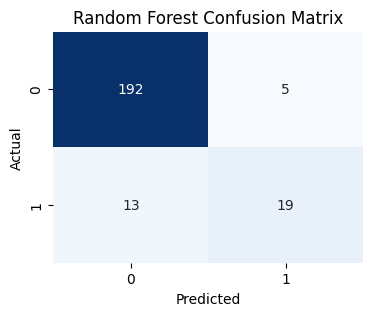


=================== Stochastic Gradient Descent (SGD) ===================
Accuracy: 0.8821

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       197
           1       0.57      0.62      0.60        32

    accuracy                           0.88       229
   macro avg       0.75      0.77      0.76       229
weighted avg       0.89      0.88      0.88       229



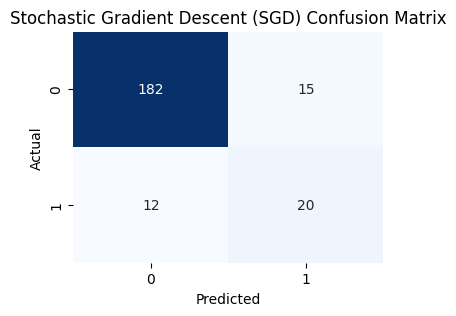


=================== Support Vector Classifier (SVC) ===================
Accuracy: 0.8996

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       197
           1       0.76      0.41      0.53        32

    accuracy                           0.90       229
   macro avg       0.84      0.69      0.74       229
weighted avg       0.89      0.90      0.89       229



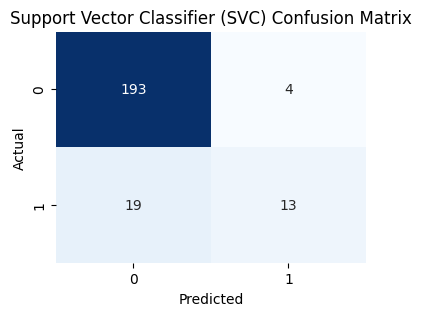

In [6]:
# Initialize the models
models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Stochastic Gradient Descent (SGD)": SGDClassifier(random_state=42),
    "Support Vector Classifier (SVC)": SVC(random_state=42)
}

# Dictionary to hold accuracy scores
accuracy_results = {}

# Train and evaluate each model step-by-step
for name, model in models.items():
    print(f"\n=================== {name} ===================")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc

    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plotting Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Model Comparison

/tmp/ipykernel_946/1468829746.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')


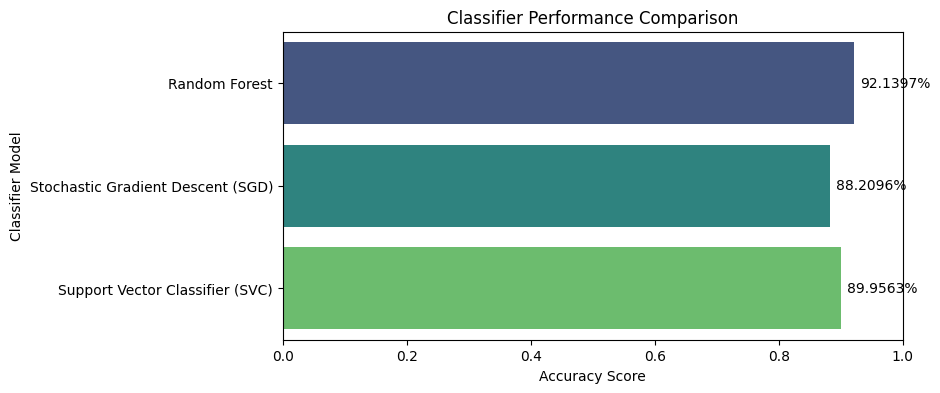

In [7]:
# Convert results to a DataFrame for plotting
df_results = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(8, 4))
sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')
plt.xlim(0, 1.0)
plt.title('Classifier Performance Comparison')
plt.xlabel('Accuracy Score')
plt.ylabel('Classifier Model')

# Display exact scores on the bars
for index, value in enumerate(df_results['Accuracy']):
    plt.text(value + 0.01, index, f"{value:.4%}", va='center')

plt.show()